![Sentimental_analysis.png](https://data-projects-cco.s3.us-east-1.amazonaws.com/Images_Project/Sentimental_analysis.png)


# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 1. Introducción:</p>


# Análisis de Reseñas para la Satisfacción del Cliente

En un mundo donde la **experiencia del cliente** es un factor clave para el éxito de cualquier negocio, analizar las **reseñas y comentarios de los usuarios** se ha convertido en una tarea fundamental. Las opiniones de los clientes proporcionan información valiosa sobre la calidad del producto o servicio, identificando **áreas de mejora** y destacando **fortalezas** que pueden potenciar la lealtad del consumidor.

Este proyecto tiene como objetivo desarrollar modelos de **deep learning** para la clasificación automática de reseñas. A través del **procesamiento de texto** y técnicas avanzadas de **redes neuronales recurrentes**, el sistema puede identificar si una reseña refleja una experiencia **positiva o negativa**.

Los resultados obtenidos a partir del modelo permiten:

✔ **Identificar tendencias y patrones** en las opiniones de los clientes.  
✔ **Mejorar la toma de decisiones estratégicas** basadas en la retroalimentación real.  
✔ **Optimizar la experiencia del usuario** al abordar problemas recurrentes de manera proactiva.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, GRU, Bidirectional, LSTM, 
    Dense, Dropout, LayerNormalization)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import bz2
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import kagglehub
import os

/Users/cristhiancamiloocampo/Documents/Proyecto_Data/Git/Data_Analytics/Sentimental_Analysis/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 2. Importación del Dataset</p>


Este script obtiene el dataset de reseñas de Amazon desde Kaggle, definiendo rutas para los archivos comprimidos y extrayendo un subconjunto de datos. Se utiliza compresión `bz2` para optimizar el acceso sin necesidad de descomprimir todo el archivo, facilitando así el manejo eficiente de grandes volúmenes de texto para su posterior procesamiento y análisis.


In [2]:


path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Path to dataset files:", path)

train_file = os.path.join(path, "train.ft.txt.bz2")
test_file = os.path.join(path, "test.ft.txt.bz2")

with bz2.BZ2File(train_file, "r") as f:
    training_data = [f.readline().decode('utf-8').strip() for _ in range(10000)]

with bz2.BZ2File(test_file, "r") as f:
    test_data = [f.readline().decode('utf-8').strip() for _ in range(2000)]

print("Training data subset size:", len(training_data))
print("Test data subset size:", len(test_data))

Path to dataset files: /Users/cristhiancamiloocampo/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7
Training data subset size: 10000
Test data subset size: 2000


In [3]:
training_data[:10]

['__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^',
 "__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",
 '__label__2 Amazing!: This sound

In [4]:
training_data[10]

"__label__1 The Worst!: A complete waste of time. Typographical errors, poor grammar, and a totally pathetic plot add up to absolutely nothing. I'm embarrassed for this author and very disappointed I actually paid for this book."

# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 3. Limpieza de datos</p>


Extrae las etiquetas y los textos de las reseñas, convirtiendo las etiquetas en formato binario. Se identifican los valores de `__label__` en cada línea del dataset, separando el texto asociado y transformando las etiquetas en 0 (negativa) y 1 (positiva) para facilitar su uso en modelos de clasificación.


In [5]:
training_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in training_data]
training_texts = [re.sub(r'__label__\d ', '', line) for line in training_data]
test_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in test_data]
test_texts = [re.sub(r'__label__\d ', '', line) for line in test_data]

training_labels = [0 if label == 1 else 1 for label in training_labels]
test_labels = [0 if label == 1 else 1 for label in test_labels]


In [6]:
print(training_labels[0])
print(training_texts[0])

1
Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^


Este código prepara las reseñas de Amazon para su análisis eliminando ruido y mejorando la representación del texto. Se descargan las stopwords de NLTK y se define una función de limpieza que convierte el texto a minúsculas, elimina caracteres no alfabéticos, remueve stopwords y aplica stemming. Finalmente, la función se aplica a los conjuntos de entrenamiento y prueba para obtener datos más limpios y uniformes para modelado.


In [7]:
nltk.download('stopwords')

def clean_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cristhiancamiloocampo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
training_texts[0]

'stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen'

# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 4. Tokenization</p>


Este código convierte las reseñas preprocesadas en secuencias numéricas utilizando `Tokenizer` de Keras. Se establece un vocabulario máximo de 1000 palabras y se ajusta el tokenizador con los textos de entrenamiento. Luego, se transforman las reseñas en secuencias de índices y se aplica padding para normalizar la longitud de las secuencias a 100 tokens, asegurando compatibilidad con modelos de deep learning.


In [9]:
max_words = 1000
max_sequence_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)

X_train = tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)


In [10]:
X_train = np.array(X_train)
print(X_train.shape)
X_test = np.array(X_test)
print(X_test.shape)
y_train = np.array(training_labels)
print(y_train.shape)
y_test = np.array(test_labels)
print(y_test.shape)

(10000, 100)
(2000, 100)
(10000,)
(2000,)


# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 5. Deep Learning</p>


### <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 5.1 Training RNN</p>

Este código define y entrena un modelo RNN optimizado para la clasificación binaria de reseñas de Amazon. Se utiliza una capa `Embedding` de 300 dimensiones para representar palabras, seguida de dos capas `SimpleRNN` con `dropout` y `LayerNormalization` para mejorar la estabilidad y reducir el sobreajuste.

El modelo se compila con la función de pérdida `binary_crossentropy` y el optimizador `Adam` con una tasa de aprendizaje reducida (`5e-5`). Se implementa `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar en 5 epochs.

El historial del entrenamiento se almacena y puede ser visualizado para evaluar la precisión y pérdida en los conjuntos de entrenamiento y validación.


In [14]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),
    SimpleRNN(128, return_sequences=True, dropout=0.3),
    LayerNormalization(),  
    SimpleRNN(128, dropout=0.3),  
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']


Epoch 1/100


/Users/cristhiancamiloocampo/Documents/Proyecto_Data/Git/Data_Analytics/Sentimental_Analysis/.env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 405ms/step - accuracy: 0.5178 - loss: 0.8760 - val_accuracy: 0.5045 - val_loss: 0.7570
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step - accuracy: 0.5156 - loss: 0.7965 - val_accuracy: 0.5010 - val_loss: 0.7191
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 408ms/step - accuracy: 0.5105 - loss: 0.7630 - val_accuracy: 0.4970 - val_loss: 0.7094
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.5049 - loss: 0.7457 - val_accuracy: 0.4980 - val_loss: 0.6987
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step - accuracy: 0.5099 - loss: 0.7305 - val_accuracy: 0.4865 - val_loss: 0.6973
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step - accuracy: 0.5125 - loss: 0.7215 - val_accuracy: 0.4980 - val_loss: 0.6939
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 390ms/step - accuracy: 0.5202 - loss: 0.7127 - val_accuracy: 0.5005 - val_loss: 0.6934
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 389ms/step - accuracy: 0.5109 - loss: 0.7146 - val_accuracy: 0.498

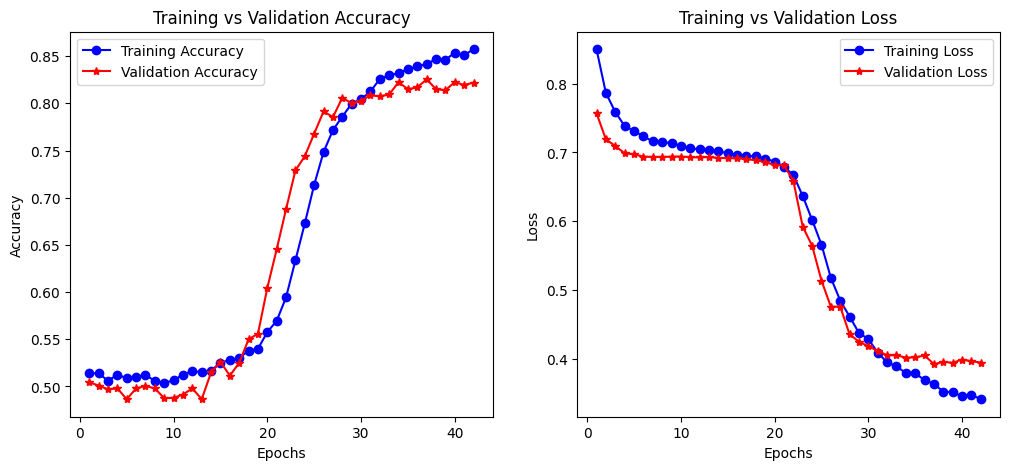

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [17]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Confusion Matrix:
[[762 192]
 [157 889]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       954
           1       0.82      0.85      0.84      1046

    accuracy                           0.83      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.83      0.83      0.83      2000



### <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 5.2 Training LSTM</p>

Este código define un modelo basado en redes LSTM bidireccionales para la clasificación binaria de reseñas. Se utiliza una capa `Embedding` de 300 dimensiones, seguida de dos capas `Bidirectional LSTM` con `recurrent_dropout` para mejorar la generalización y `LayerNormalization` para estabilizar el entrenamiento.

El modelo se compila con `binary_crossentropy` y el optimizador `Adam` con una tasa de aprendizaje baja (`5e-5`). Se incorpora `EarlyStopping` para detener el entrenamiento si la pérdida de validación deja de mejorar en 5 épocas.

Este diseño busca mejorar la captura de dependencias en secuencias de texto, aprovechando la naturaleza bidireccional de las LSTM para capturar contexto tanto pasado como futuro.


In [18]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),  
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)


Epoch 1/100


/Users/cristhiancamiloocampo/Documents/Proyecto_Data/Git/Data_Analytics/Sentimental_Analysis/.env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5128 - loss: 0.7887 - val_accuracy: 0.5655 - val_loss: 0.6823
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5371 - loss: 0.7087 - val_accuracy: 0.6005 - val_loss: 0.6710
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5788 - loss: 0.6795 - val_accuracy: 0.6415 - val_loss: 0.6528
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6059 - loss: 0.6571 - val_accuracy: 0.6770 - val_loss: 0.6214
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.6590 - loss: 0.6195 - val_accuracy: 0.7095 - val_loss: 0.5709
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.7068 - loss: 0.5617 - val_accuracy: 0.7380 - val_loss: 0.5294
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7520 - loss: 0.5124 - val_accuracy: 0.7640 - val_loss: 0.5017
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.7782 - loss: 0.4624 - val_accuracy: 0.7765 - val_loss: 0.4

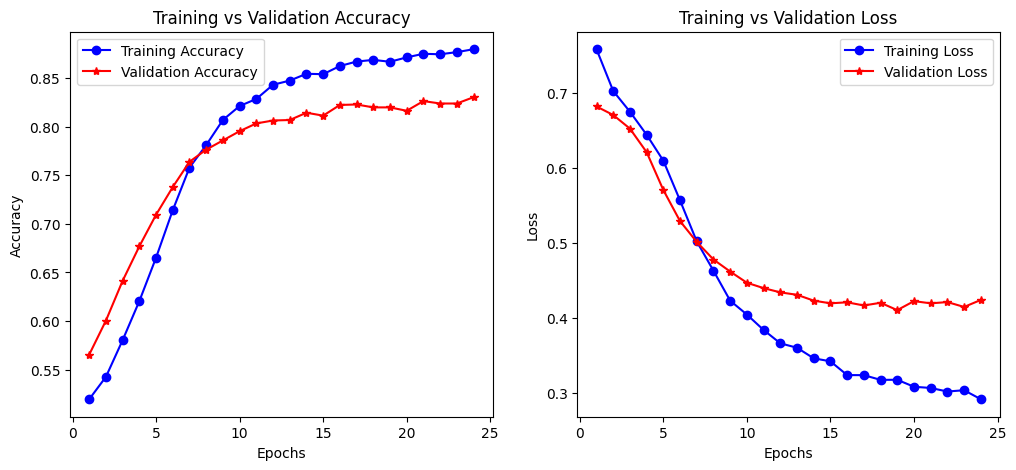

In [19]:
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [20]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step
Confusion Matrix:
[[761 193]
 [167 879]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       954
           1       0.82      0.84      0.83      1046

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



### <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 5.3 Training GRU</p>

Este código implementa un modelo basado en redes GRU para la clasificación binaria de textos. Se utiliza una capa `Embedding` de 300 dimensiones para representar palabras en un espacio vectorial. Luego, se incluyen dos capas `GRU` con `dropout` y `recurrent_dropout` para mejorar la capacidad de generalización y evitar sobreajuste.

Se incorpora `LayerNormalization` después de cada capa `GRU` para estabilizar el aprendizaje. Además, se agregan capas `Dropout` y una capa `Dense` con activación ReLU antes de la salida sigmoidal.

El modelo se optimiza con `Adam` usando una tasa de aprendizaje baja (`5e-5`) y se emplea `EarlyStopping` para evitar entrenamiento innecesario si la pérdida de validación no mejora en 5 épocas.


In [21]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),
    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    LayerNormalization(),
    GRU(128, dropout=0.3, recurrent_dropout=0.2),
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"), 
    Dropout(0.2),
    Dense(1, activation='sigmoid') 
])

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=100, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

Epoch 1/100


/Users/cristhiancamiloocampo/Documents/Proyecto_Data/Git/Data_Analytics/Sentimental_Analysis/.env/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 938ms/step - accuracy: 0.5074 - loss: 0.9048 - val_accuracy: 0.5365 - val_loss: 0.7386
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5302 - loss: 0.8219 - val_accuracy: 0.5700 - val_loss: 0.6892
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.5488 - loss: 0.7821 - val_accuracy: 0.6005 - val_loss: 0.6613
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5524 - loss: 0.7527 - val_accuracy: 0.6170 - val_loss: 0.6440
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.5645 - loss: 0.7286 - val_accuracy: 0.6305 - val_loss: 0.6318
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5853 - loss: 0.7063 - val_accuracy: 0.6405 - val_loss: 0.6218
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6070 - loss: 0.6842 - val_accuracy: 0.6500 - val_loss: 0.6124
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6006 - loss: 0.6839 - val_accuracy: 0.6610 - val_loss: 

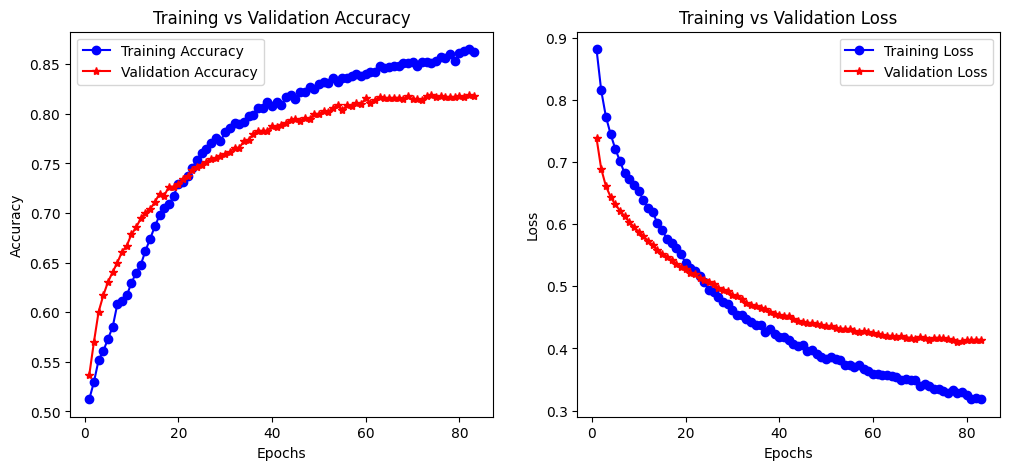

In [22]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [23]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step
Confusion Matrix:
[[740 214]
 [153 893]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       954
           1       0.81      0.85      0.83      1046

    accuracy                           0.82      2000
   macro avg       0.82      0.81      0.82      2000
weighted avg       0.82      0.82      0.82      2000



# <p style="background-color: rgb(4, 153, 227); font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:50px 50px; margin-top:5px; margin-bottom:5px;"> 6. Resultados</p>


In [27]:
def predict_sentiment(text, model, tokenizer, max_sequence_length=100):

    text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)
    prediction = model.predict(padded_sequence)[0][0] 
    
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😡"
    
    return sentiment, float(prediction)

#Ejemplo de uso
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.9949)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.0265)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Negative 😡 (Confidence: 0.4423)



In [25]:
model.save("lstm_model.h5")
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
